* code 말고 markdown으로 입려하려면

Esc -> m -> 내용 적고 -> Shift +Enter


[참고]
1. Chem이 의미하는 것

Chem은 RDKit에서 가장 핵심적인 모듈. 분자를 읽고, 쓰고, 원자를 추가하거나 삭제하는 등 '화학적인 연산'에 필요한 거의 모든 기능이 이 안에 들어있다.

EX)

Chem.MolFromSmiles(): 스마일즈로 분자 만들기

Chem.AddHs(): 수소 원자 추가하기

Chem.MolToMolBlock(): 분자 데이터를 텍스트로 바꾸기

2. 왜 항상 앞에 Chem.을 붙이는가?

파이썬의 '이름 공간(Namespace)' 규칙 때문.

만약 Chem.을 붙이지 않고 그냥 AddHs()라고만 쓰면, 파이썬은 이 함수가 RDKit 것인지, 아니면 다른 라이브러리(예: Pandas나 Custom 함수) 것인지 알 수가 없다.

EX)

from rdkit import Chem: "RDKit에서 Chem이라는 도구함을 가져오겠다"는 선언.

Chem.AddHs(): "Chem 도구함 안에 있는 AddHs라는 도구를 꺼내 쓰겠다"는 뜻.

In [1]:
import rdkit

In [2]:
from rdkit import Chem

# 2강: 여러개의 분자들을 압축 파일로 쓰고, 분자의 3차원 구조를 계산하고 분자들의 Fingerprint 계산

- 압축파일을 읽기위해서 gzip 모듈을 읽어들여야 한다.

In [3]:
import gzip

- 파일을 오픈한다.

In [4]:
fp = gzip.open("data/actives_5ht3.sdf.gz")

In [9]:
suppl = Chem.ForwardSDMolSupplier(fp)     
# Chem.ForwardSDMolSupplier() 는 SD 파일(.sdf)을 처음부터 끝까지 순차적으로 읽어오는 도구.
# SDF파일에서 분자 한개씩 꺼내서 읽어들인다.
# SDMolSupplier와 다르게 단방향성이다. (앞에서 쭉읽어들이기만 가능하고 특정 인덱스로 바로 이동은 불가능)

In [7]:
type(suppl)     #suppl 이라는 변수의 유형을 묻는 명령어

rdkit.Chem.rdmolfiles.ForwardSDMolSupplier

# 여러개의 분자를 차례차례 읽어서 하나의 리스트로 저장할때 list comprhension을 이용하면 빠르고 효율적이다.

In [13]:
# m이 None(분자 문제가 있을 때)이 아니면, 즉 분자에 문제가 없으면 supple이라는 파일에서 하나씩 꺼내서 mols라는 리스트에 저장해라
mols = [m for m in suppl if m is not None]


In [15]:
len(mols)     # 파이썬의 내장 함수로, 객체에 담긴 요소의 개수(길이)를 의미한다.

180

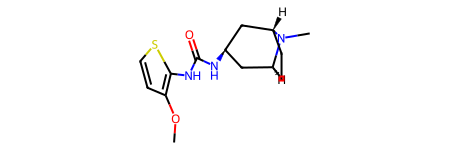

In [16]:
mols[0]

mols[1]

# 분자들의 리스트가 있을때, 파일로 저장하기

- SDWriter 사용

In [20]:
with Chem.SDWriter("mols.sdf") as fout:
  for m in mols:
    fout.write(m)

with Chem.SDWriter("mols.sdf") as fout:
=> 의미: mols.sdf라는 이름의 SDF 파일을 새로 만들고, 이를 작성할 도구(Writer)를 실행해 fout이라는 별명으로 부른다.
=> 핵심: with 문법 덕분에 작업이 끝나거나 에러가 나도 파일을 자동으로 닫고 저장한다.

for m in mols:
=> 의미: mols라는 묶음(리스트나 Supplier 객체 등) 안에 들어있는 분자 객체들을 하나씩 꺼내어 m이라는 변수에 담아 반복한다.

fout.write(m)
=> 의미: 꺼내진 분자 m을 아까 열어둔 파일(fout)에 실제로 기록(Write)한다.

# 수소를 붙여보자!

* Chem.AddHs 함수로 수소를 붙인다.
  
  => 주의할점: AddHs를 사용하면 새로운 분자를 리턴한다.

In [24]:
m1 = mols[0]

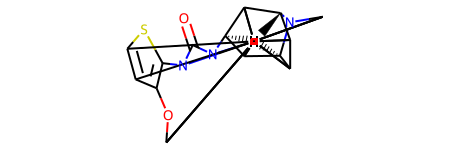

In [28]:
Chem.AddHs(m1)     # 이렇게 실행하면 m1은 바뀌지 않고 그대로 유지. 새로운 변수에 새로운 분자를 지정해야함.

In [33]:
print(Chem.MolToMolBlock(m1))     # 즉, 28, 26번 처럼 하면 안되고 29, 33번처럼 해야한다.

tpls\mol-1.tpl
     RDKit          3D

 20 22  0  0  0  0  0  0  0  0999 V2000
    1.1200   -0.6200   -1.0800 C   0  0  2  0  0  0  0  0  0  0  0  0
    1.5400    0.8200   -1.0600 N   0  0  0  0  0  0  0  0  0  0  0  0
   -0.4200   -0.6400   -1.3200 C   0  0  0  0  0  0  0  0  0  0  0  0
    1.5600   -1.1800    0.3000 C   0  0  0  0  0  0  0  0  0  0  0  0
    1.1400    1.2200    0.3200 C   0  0  2  0  0  0  0  0  0  0  0  0
    2.9600    1.0600   -1.3800 C   0  0  0  0  0  0  0  0  0  0  0  0
   -1.2400    0.2400   -0.3000 C   0  0  2  0  0  0  0  0  0  0  0  0
    1.5600    0.0600    1.2400 C   0  0  0  0  0  0  0  0  0  0  0  0
   -0.4200    1.4600    0.2600 C   0  0  0  0  0  0  0  0  0  0  0  0
   -1.7800   -0.5600    0.7600 N   0  0  0  0  0  0  0  0  0  0  0  0
   -2.6400   -0.1600    1.7400 C   0  0  0  0  0  0  0  0  0  0  0  0
   -3.0600   -1.0400    2.6800 N   0  0  0  0  0  0  0  0  0  0  0  0
   -3.0200    1.0000    1.7600 O   0  0  0  0  0  0  0  0  0  0  0  0
   -3.9400 

In [29]:
m2 = Chem.AddHs(m1)

In [30]:
print(Chem.MolToMolBlock(m2))

tpls\mol-1.tpl
     RDKit          3D

 41 43  0  0  0  0  0  0  0  0999 V2000
    1.1200   -0.6200   -1.0800 C   0  0  1  0  0  0  0  0  0  0  0  0
    1.5400    0.8200   -1.0600 N   0  0  0  0  0  0  0  0  0  0  0  0
   -0.4200   -0.6400   -1.3200 C   0  0  0  0  0  0  0  0  0  0  0  0
    1.5600   -1.1800    0.3000 C   0  0  0  0  0  0  0  0  0  0  0  0
    1.1400    1.2200    0.3200 C   0  0  1  0  0  0  0  0  0  0  0  0
    2.9600    1.0600   -1.3800 C   0  0  0  0  0  0  0  0  0  0  0  0
   -1.2400    0.2400   -0.3000 C   0  0  1  0  0  0  0  0  0  0  0  0
    1.5600    0.0600    1.2400 C   0  0  0  0  0  0  0  0  0  0  0  0
   -0.4200    1.4600    0.2600 C   0  0  0  0  0  0  0  0  0  0  0  0
   -1.7800   -0.5600    0.7600 N   0  0  0  0  0  0  0  0  0  0  0  0
   -2.6400   -0.1600    1.7400 C   0  0  0  0  0  0  0  0  0  0  0  0
   -3.0600   -1.0400    2.6800 N   0  0  0  0  0  0  0  0  0  0  0  0
   -3.0200    1.0000    1.7600 O   0  0  0  0  0  0  0  0  0  0  0  0
   -3.9400 

* 수소의 좌표가 존재하지 않음...

  => 애초에 mols.sdf 파일에 수소의 x, y, z 좌표 정보가 없기 때문

  => 좌표를 지정해줘야한다.

* 수소를 지울 때는 Chem.RemoveHs 함수를 사용

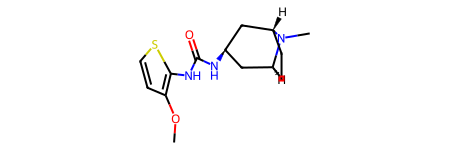

In [36]:
Chem.RemoveHs(m2)

In [39]:
print(Chem.MolToMolBlock(Chem.RemoveHs(m2)))

# m2에서 수소를 제거한 분자를 MolBlock(Mol file[MDL mol format])으로 지정한다.

tpls\mol-1.tpl
     RDKit          3D

 20 22  0  0  0  0  0  0  0  0999 V2000
    1.1200   -0.6200   -1.0800 C   0  0  2  0  0  0  0  0  0  0  0  0
    1.5400    0.8200   -1.0600 N   0  0  0  0  0  0  0  0  0  0  0  0
   -0.4200   -0.6400   -1.3200 C   0  0  0  0  0  0  0  0  0  0  0  0
    1.5600   -1.1800    0.3000 C   0  0  0  0  0  0  0  0  0  0  0  0
    1.1400    1.2200    0.3200 C   0  0  2  0  0  0  0  0  0  0  0  0
    2.9600    1.0600   -1.3800 C   0  0  0  0  0  0  0  0  0  0  0  0
   -1.2400    0.2400   -0.3000 C   0  0  2  0  0  0  0  0  0  0  0  0
    1.5600    0.0600    1.2400 C   0  0  0  0  0  0  0  0  0  0  0  0
   -0.4200    1.4600    0.2600 C   0  0  0  0  0  0  0  0  0  0  0  0
   -1.7800   -0.5600    0.7600 N   0  0  0  0  0  0  0  0  0  0  0  0
   -2.6400   -0.1600    1.7400 C   0  0  0  0  0  0  0  0  0  0  0  0
   -3.0600   -1.0400    2.6800 N   0  0  0  0  0  0  0  0  0  0  0  0
   -3.0200    1.0000    1.7600 O   0  0  0  0  0  0  0  0  0  0  0  0
   -3.9400 

In [43]:
print(Chem.MolToMolFile(Chem.RemoveHs(m2)))

# MolToMolBlock은 결과물을 화면(텍스트)에 뿌려주지만, MolToMolFile은 결과물을 컴퓨터 파일(.mol)로 저장하는 함수입니다.

# Chem.MolToMolFile은 다음과 같은 형식으로 명령해야한다. Chem.MolToMolFile(분자, "data/파일명")

ArgumentError: Python argument types in
    rdkit.Chem.rdmolfiles.MolToMolFile(Mol)
did not match C++ signature:
    MolToMolFile(class RDKit::ROMol mol, class std::basic_string<char,struct std::char_traits<char>,class std::allocator<char> > filename, bool includeStereo=True, int confId=-1, bool kekulize=True, bool forceV3000=False)
    MolToMolFile(class RDKit::ROMol mol, class std::basic_string<char,struct std::char_traits<char>,class std::allocator<char> > filename, struct RDKit::MolWriterParams params, int confId=-1)

- MolToMolBlock은 결과물을 화면(텍스트)에 뿌려주지만, MolToMolFile은 결과물을 컴퓨터 파일(.mol)로 저장하는 함수이다.

- Chem.MolToMolFile은 다음과 같은 형식으로 명령해야한다.

- Chem.MolToMolFile(분자, "data/파일명")

- Chem.MolToMolFile(m4, "data/test.mol") # m4를 test.mol 파일로 저장하겠다.

- Chem.MolToPDBFile(m4, "data/test.pdb") #m4를 test.pdb 파일로 저장하겠다.

In [44]:
Chem.MolToMolFile(Chem.RemoveHs(m2), "data/m2.mol")

# 분자의 3차원 구조 만들기

- 분자의 정확한 3차원 구조 (crystal structure)를 알아내는 것은 여전히 어려운 문제!
- 정확한 3차원 구조를 얻기 위해서는 양자 계산 및 전역 최적화 계산이 필요하다.
- 회전가능한 bond 개수 많을수록 기하급수적으로 가능한 구조의 개수가 늘어나게 된다.
- 모든 분자의 3차원 생성코드는 일정한 가정 하에 진행한다. approximation 방법이라고 생각하면 된다.
- RDKit 안에는 ETKDG 라는 방법이 구현되어음.

- 3차원 구조를 얻기위한 함수 이름: EmbedMolecule => AllChem이라는 모듈에 존재한다. (Chem 모듈의 Sub 모듈이 AllChem 모듈)

In [47]:
from rdkit.Chem import AllChem    # AllChem 안에는 더 다양하고 advanced 방법들이 들어 있음.

* AllChem.EmbedMolecule 함수를 사용하면 된다
* AllChem.EmbedMolecule 함수는 입력받은 변수를 그 자리에서 변화 시킴 (in-place).

In [49]:
AllChem.EmbedMolecule(m2)     # Error가 나지 않으면  0이 출력된다.

0

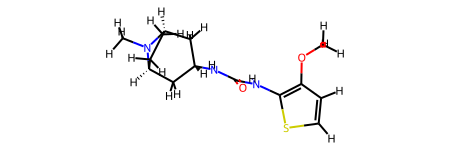

In [50]:
m2

In [53]:
print(Chem.MolToMolBlock(m2))
# 3차원 구조로 불러들이고 수소의 좌표가 제대로 출력되는지 확인
# 여기서 m2 위치에 있는(내가 3차원 구조를 확인하고 싶은) 분자는 수소가 포함되어있는 분자여야한다. (Chem.AddHs())

tpls\mol-1.tpl
     RDKit          3D

 41 43  0  0  0  0  0  0  0  0999 V2000
   -3.6229   -0.2641    0.1194 C   0  0  2  0  0  0  0  0  0  0  0  0
   -3.7173    0.8716    0.9847 N   0  0  0  0  0  0  0  0  0  0  0  0
   -2.3261   -0.9732    0.3834 C   0  0  0  0  0  0  0  0  0  0  0  0
   -3.5661    0.2478   -1.3006 C   0  0  0  0  0  0  0  0  0  0  0  0
   -2.7770    1.7728    0.3743 C   0  0  2  0  0  0  0  0  0  0  0  0
   -5.0346    1.3896    1.1648 C   0  0  0  0  0  0  0  0  0  0  0  0
   -1.1635   -0.1065    0.6659 C   0  0  2  0  0  0  0  0  0  0  0  0
   -2.8822    1.5980   -1.1051 C   0  0  0  0  0  0  0  0  0  0  0  0
   -1.4083    1.3396    0.8792 C   0  0  0  0  0  0  0  0  0  0  0  0
   -0.1185   -0.3067   -0.3503 N   0  0  0  0  0  0  0  0  0  0  0  0
    1.1304   -0.8959    0.0021 C   0  0  0  0  0  0  0  0  0  0  0  0
    2.1405   -1.0841   -1.0041 N   0  0  0  0  0  0  0  0  0  0  0  0
    1.4214   -1.2728    1.1573 O   0  0  0  0  0  0  0  0  0  0  0  0
    3.4006 

In [54]:
m3 = Chem.MolFromSmiles("c1ccccc1")

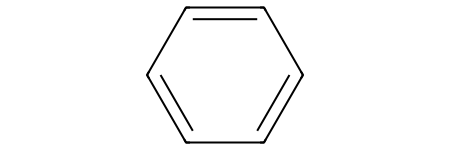

In [55]:
m3

In [58]:
print(Chem.MolToMolBlock(m3))
# 수소가 없는 벤젠


     RDKit          2D

  6  6  0  0  0  0  0  0  0  0999 V2000
    1.5000    0.0000    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    0.7500   -1.2990    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
   -0.7500   -1.2990    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
   -1.5000    0.0000    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
   -0.7500    1.2990    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    0.7500    1.2990    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
  1  2  2  0
  2  3  1  0
  3  4  2  0
  4  5  1  0
  5  6  2  0
  6  1  1  0
M  END



In [59]:
m4 = Chem.AddHs(m3)

In [60]:
print(Chem.MolToMolBlock(m4))


     RDKit          2D

 12 12  0  0  0  0  0  0  0  0999 V2000
    1.5000    0.0000    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    0.7500   -1.2990    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
   -0.7500   -1.2990    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
   -1.5000    0.0000    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
   -0.7500    1.2990    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    0.7500    1.2990    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    3.0000    0.0000    0.0000 H   0  0  0  0  0  0  0  0  0  0  0  0
    1.5000   -2.5981    0.0000 H   0  0  0  0  0  0  0  0  0  0  0  0
   -1.5000   -2.5981    0.0000 H   0  0  0  0  0  0  0  0  0  0  0  0
   -3.0000    0.0000    0.0000 H   0  0  0  0  0  0  0  0  0  0  0  0
   -1.5000    2.5981    0.0000 H   0  0  0  0  0  0  0  0  0  0  0  0
    1.5000    2.5981    0.0000 H   0  0  0  0  0  0  0  0  0  0  0  0
  1  2  2  0
  2  3  1  0
  3  4  2  0
  4  5  1  0
  5  6  2  0
  6  1  1  0
  1  7  1  0
  2 

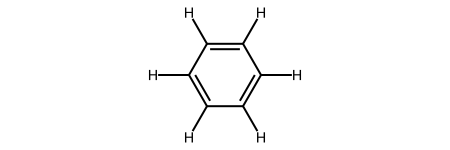

In [61]:
m4

In [62]:
AllChem.EmbedMolecule(m4)

0

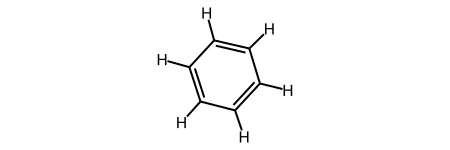

In [63]:
m4

In [64]:
print(AllChem.MolToMolBlock(m4))


     RDKit          3D

 12 12  0  0  0  0  0  0  0  0999 V2000
   -1.3620    0.3067    0.0022 C   0  0  0  0  0  0  0  0  0  0  0  0
   -0.9369   -1.0052    0.0315 C   0  0  0  0  0  0  0  0  0  0  0  0
    0.3842   -1.3439    0.0303 C   0  0  0  0  0  0  0  0  0  0  0  0
    1.3357   -0.3167   -0.0018 C   0  0  0  0  0  0  0  0  0  0  0  0
    0.9293    1.0221   -0.0318 C   0  0  0  0  0  0  0  0  0  0  0  0
   -0.4155    1.3331   -0.0298 C   0  0  0  0  0  0  0  0  0  0  0  0
   -2.4044    0.5984    0.0025 H   0  0  0  0  0  0  0  0  0  0  0  0
   -1.6626   -1.8087    0.0565 H   0  0  0  0  0  0  0  0  0  0  0  0
    0.7315   -2.3584    0.0528 H   0  0  0  0  0  0  0  0  0  0  0  0
    2.4044   -0.5776   -0.0031 H   0  0  0  0  0  0  0  0  0  0  0  0
    1.6961    1.7732   -0.0558 H   0  0  0  0  0  0  0  0  0  0  0  0
   -0.6997    2.3771   -0.0535 H   0  0  0  0  0  0  0  0  0  0  0  0
  1  2  2  0
  2  3  1  0
  3  4  2  0
  4  5  1  0
  5  6  2  0
  6  1  1  0
  1  7  1  0
  2 

# Chemical FingerPrints

- 분자 구조를 정해진 차원의 정수의 벡터로 변환하는 방법
- 목적: 동일하거나 비슷한 분자를 빠르게 검색하기 위해서 많이 사용된다.
- 컴퓨터를 이용해서 2차원의 분자 구조나 1차원 텍스트를 비교하는 것보다 1차원 정수 벡터를 비교하는 것이 빠르다.

* FingerPrints 종류
1) MACCS Key

   자주 관찰되는 분자의 부분 구조를 미리 정한 후에 그 구조가 존재하는지 아닌지를 0과 1로 표현
   
3) Morgan Algorithm


   분자의 구조를 정수로 표현하기 위한 방법
   Step 1. 각 원자에 연결된 원자의 개수를 부여한다. (connectivity)
   Step 2. 각 원자들에 연결된 원자의 connectivity 값을 모두 합한 값을 그 원자의 connectivity 값으로 다시 부여한다.
   Step 3. 2번 과정을 반복한다.
   Step 4. 각 원자가 가지는 값이 더이상 변화하지 않을 때 반복을 멈춘다.

   
4) ECFP

    Morgan Algorithm과 유사.
    원자번호, mass, charge 등의 정보를 가지고 하나의 Hash values를 가지게 된다.

   Hash function: 임의의 길이의 데이터를 고정된 길이의 데이터로 매핑하는 함수이며 여기서 얻어지는 값을 해시 값, 해시 코드, 해시 체크섬 또는 간단하게 해시라고한다.

    해시 함수의 목적

   - 대용량의 데이터가 저장되어 있을 때, 특정 데이터를 찾거나 동일한지 아닌지를 매우 빠르게 판단할 수 있다.
   - 해시 값이 동일하지 않으며 두 파일이 다른 파일이다.
   - 그러나 해시 값이 같더라도 두 파일이 서로 다를 가능성이 존재한다. (해시 충돌. collision)
   - 해시 값의 사이즈가 작으면 검색 속도는 빠르지만 충돌 확률은 증가한다.
   - 반대로 해시 값의 사이즈가 크면 충돌 확률은 낮아지지만 검색의 속도는 느려진다.

# RDKit fingerprints
= Topological Fingerprints

In [65]:
from rdkit import DataStructs

In [66]:
ms = [Chem.MolFromSmiles('CCOC'), Chem.MolFromSmiles('CCO'),
Chem.MolFromSmiles('COC')]

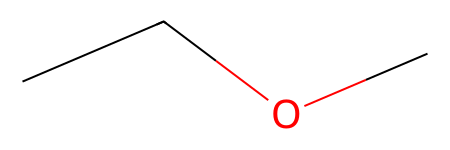

In [67]:
ms[0]

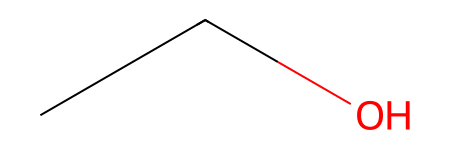

In [68]:
ms[1]

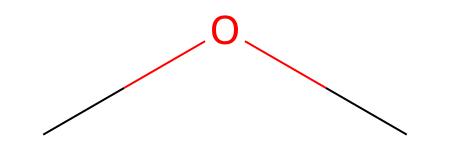

In [69]:
ms[2]

In [71]:
type(ms[0])

rdkit.Chem.rdchem.Mol

Mol type의 변수로부터 fingerprints를 만드는 방법
Chem.RDKFingerprint() for ? in  ??

In [74]:
fps = [Chem.RDKFingerprint(m) for m in ms]

In [75]:
fps [0]

In [76]:
fps[1]

In [77]:
fps[2]

In [79]:
for x in fps[0]:
    print(x)

0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
1
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
1
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0


In [82]:
for idx, x in enumerate(fps[0]):
    if x==1:
        print(idx, x)
print("Last digit: ", idx)

121 1
308 1
562 1
1183 1
1308 1
1339 1
1728 1
1772 1
1941 1
1960 1
Last digit:  2047


* 해석
  
for idx, x in enumerate(fps[0]):
    if x==1:
        print(idx, x)
print("Last digit: ", idx)

fps[0]: 여러 개의 핑거프린트가 담긴 리스트(fps) 중 첫 번째 분자의 데이터
enumerate(): 데이터를 하나씩 꺼낼 때, 그 데이터가 몇 번째인지 알려주는 번호(idx)와 실제 값(x)을 동시에 반환
idx: 핑거프린트 내의 비트 위치(번호)
x: 해당 위치의 비트 값(보통 0 또는 1)

if x == 1: : 꺼낸 비트 값(x)이 1인지 확인(해당 분자에 특정 부분 구조(Substructure)가 존재하는가?)

print(idx, x) : 조건이 참일때, 비트 번호(idx)와 값(x) 출력

print("Last digit: ", idx) : 마지막으로 확인한 인덱스 번호(idx)가 무엇인지 (여기서 출력된 값+1 이 전체 개수를 의미)

- 유사도 계산

  DataStructs.FingerprintSimilarity( , )
  DataStructs.TanimotoSmilarity( , )

In [83]:
DataStructs.TanimotoSimilarity(fps[0],fps[1])

0.6

* 유사도는 일반적으로 TanimotoSimilarity 이용
* 두개의 벡터가 있을때 (0과 1의 교집합의 개수)/(합집합의 개수)

In [86]:
DataStructs.TanimotoSimilarity(fps[1],fps[2])

0.25

In [87]:
DataStructs.TanimotoSimilarity(fps[0],fps[2])

0.4

In [92]:
DataStructs.TanimotoSimilarity(fps[0],fps[2], metric=DataStructs.DiceSimilarity) # Dice similarity를 사용하겠다.
# 오류 원인....

ArgumentError: Python argument types in
    rdkit.DataStructs.cDataStructs.TanimotoSimilarity(ExplicitBitVect, ExplicitBitVect)
did not match C++ signature:
    TanimotoSimilarity(class RDKit::SparseIntVect<unsigned __int64> siv1, class RDKit::SparseIntVect<unsigned __int64> siv2, bool returnDistance=False, double bounds=0.0)
    TanimotoSimilarity(class RDKit::SparseIntVect<unsigned int> siv1, class RDKit::SparseIntVect<unsigned int> siv2, bool returnDistance=False, double bounds=0.0)
    TanimotoSimilarity(class RDKit::SparseIntVect<__int64> siv1, class RDKit::SparseIntVect<__int64> siv2, bool returnDistance=False, double bounds=0.0)
    TanimotoSimilarity(class RDKit::SparseIntVect<int> siv1, class RDKit::SparseIntVect<int> siv2, bool returnDistance=False, double bounds=0.0)
    TanimotoSimilarity(class ExplicitBitVect bv1, class std::basic_string<char,struct std::char_traits<char>,class std::allocator<char> > pkl, bool returnDistance=0)
    TanimotoSimilarity(class SparseBitVect bv

In [93]:
DataStructs.FingerprintSimilarity(fps[0],fps[1])

0.6

In [94]:
DataStructs.FingerprintSimilarity(fps[0],fps[1], metric=DataStructs.DiceSimilarity)

0.75

- 트러블 슈팅

DataStructs.TanimotoSimilarity(fps[0],fps[1], metric=DataStructs.DiseSimilarity)
와
DataStructs.FingerprintSimilarity(fps[0],fps[1], metric=DataStructs.DiceSimilarity)

를 실행했을때 다른 결과가 나온 이유

FingerprintSimilarity와 TanimotoSimilarity는 옵션 허용 여부가 다르게 설계되어있음.
전자의 경우 사용자가 계산 방식(metric)을 직접 선택할 수 있도록 설계된 함수로
metric=DataStructs.DiceSimilarity라고 지정하면 내부적으로 Dice 공식을 사용하고, metric을 따로 안 쓰면 기본값으로 Tanimoto를 사용한다. (때문에 metric을 쓰지 않은 FingerprintSimilarity와 TanimotoSimilarity의 결과값이 같았던 것.)

후자의 경우 오직 Tanimoto 계산만 수행하는 단일 목적 함수로 내부족으로 metric 라는 선택지를 가지고 있지 않아서 Dice 함수로 지정을 해도 '나는 Tanimoto만 할 수 있는데 왜 Dice를 하래....' 가 되는 것.

# MACCS Keys

In [95]:
from rdkit.Chem import MACCSkeys

- Fingerprint 생성

In [96]:
fps = [MACCSkeys.GenMACCSKeys(x) for x in ms]

In [97]:
fps[0]

In [98]:
for idx, x in enumerate(fps[0]):
    if x==1:
        print(idx, x)
print("Last digit: ", idx)

86 1
93 1
109 1
114 1
115 1
126 1
149 1
153 1
155 1
157 1
160 1
164 1
Last digit:  166


* MACCS 기반으로 (166차원의 0/1 벡터를 기반으로) Tanimoto similarity 계산

In [100]:
DataStructs.FingerprintSimilarity(fps[0],fps[1]) # Taniimoto similarity

0.5

In [101]:
DataStructs.FingerprintSimilarity(fps[2],fps[1]) # Taniimoto similarity

0.21428571428571427

In [102]:
DataStructs.FingerprintSimilarity(fps[0],fps[2]) # Taniimoto similarity

0.5384615384615384

# Morgan Fingerprints (ECFP)

ECFP를 사용할때는 AllChem이 필요하다. (이미 불러와서 여기서는 다시 안 부름)

from rdkit.Chem import AllChem

In [105]:
# ECFP는 radius를 정해야한다. (각 중심 원자에서 얼만큼 떨어진 이웃한 원자까지 고려한지)
# 각 atom을 기준으로 바로 옆에 있는 것만 볼건지 (radius=1), 바로 옆에 있는 거랑 그 옆에 있는 것을 볼건지 (radius=2)
# radius=1, ECFP2    /    radius=2, ECPF4
fpgen = AllChem.GetMorganGenerator(radius=2)

In [107]:
fps = [fpgen.GetSparseCountFingerprint(x) for x in ms]

In [108]:
fps [0]

In [109]:
fpss = [AllChem.GetMorganFingerprint(x,2) for x in ms]

[21:50:48] DEPRECATION WARNING: please use MorganGenerator
[21:50:48] DEPRECATION WARNING: please use MorganGenerator
[21:50:48] DEPRECATION WARNING: please use MorganGenerator


fpgen = AllChem.GetmorganGenerator(radius=n)
fps = [fpgen.GetSparseCountFingerprint(x) for x in ms]

분자 내 특징들의 위치와 발생 횟수(Count)를 메모리 효율적(Sparse)으로 추출해라

In [111]:
for x in fps[0]:
    if x !=0:
        print(x)

Unexpected exception formatting exception. Falling back to standard exception


Traceback (most recent call last):
  File "C:\Users\LG\.conda\envs\rdkit_study\lib\site-packages\IPython\core\interactiveshell.py", line 3398, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "C:\Users\LG\AppData\Local\Temp\ipykernel_42104\198934488.py", line -1, in <cell line: 1>
KeyboardInterrupt

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "C:\Users\LG\.conda\envs\rdkit_study\lib\site-packages\IPython\core\interactiveshell.py", line 1993, in showtraceback
    stb = self.InteractiveTB.structured_traceback(
  File "C:\Users\LG\.conda\envs\rdkit_study\lib\site-packages\IPython\core\ultratb.py", line 1118, in structured_traceback
    return FormattedTB.structured_traceback(
  File "C:\Users\LG\.conda\envs\rdkit_study\lib\site-packages\IPython\core\ultratb.py", line 1012, in structured_traceback
    return VerboseTB.structured_traceback(
  File "C:\Users\LG\.conda\envs\rdkit_study\lib\site-packages

위에 명령어는 오래걸려서 멈춘것

첫 번째 핑거프린트(fps[0]) 내에서 값이 0이 아닌 비트(즉, 1 이상인 값)를 찾아 그 값을 화면에 출력

x !=0
=> x가 0이 아닐 때

In [113]:
DataStructs.DiceSimilarity(fps[0],fps[1])

0.4

Morgan fingerprint를 정수의 리스트가 아니라 Bit vector로 얻기 위해서 아래의 코드를 사용한다.

fp1 = fpgen.GetFingerprint(m1)

여기서 비트 수는 기본값이 2048이기 때문에 1024로 바꿔주려면 아래의 단계로 진행해야한다.

In [114]:
# 1. 생성기 단계에서 1024비트로 고정
fpgen = AllChem.GetMorganGenerator(radius=2, fpSize=1024)

In [115]:
# 2. 이제 이 함수는 1024비트 비트 벡터를 반환합니다.
fps = [fpgen.GetFingerprint(x) for x in ms]

In [117]:
fps [0]

* 기본적으로 2048 비트를 사용할 때는 아래와 같은 명령어를 사용

fpgen = AllChem.GetMorganGenerator(radius=2)
fp1 = fpgen.GetFingerprint(m1)     # 리스트 없을 때
or
fps = [fpgen.GetFingerprint(x) for x in ms]   # 리스트 있을 때

In [118]:
for idx, x in enumerate(fps[0]):
    if x==1:
        print(idx, x)
print("Last digit: ", idx)

33 1
80 1
214 1
294 1
695 1
817 1
841 1
1005 1
Last digit:  1023


* 1024개의 bit로 분자가 변환되었다는 것을 알 수 있다.

In [121]:
fpgen2 = AllChem.GetMorganGenerator(radius=2)
fps = [fpgen2.GetFingerprint(x) for x in ms]

In [122]:
fps[0]

In [123]:
for idx, x in enumerate(fps[0]):
    if x==1:
        print(idx, x)
print("Last digit: ", idx)

80 1
294 1
695 1
817 1
841 1
1005 1
1057 1
1238 1
Last digit:  2047


- 1024개의 bit로 분자가 변환되었다는 것을 알 수 있다.

In [124]:
DataStructs.DiceSimilarity(fps[0],fps[1])

0.42857142857142855

In [125]:
DataStructs.FingerprintSimilarity(fps[0],fps[1])

0.2727272727272727

[응용]

거대한 분자 라이브러리에서 특정 분자와 얼마 이상으로 비슷한 분자만 고를 때 

특정 분자와 얼마 이상으로 비슷한 분자는 빼고 많이 다른 것들만 고를 때